In [ ]:
# ==========================================================
# TASK 1: IMPORT REQUIRED LIBRARIES
# ==========================================================

# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    Dropout
)

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Display TensorFlow version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# ==========================================================
# TASK 2: LOAD AND EXPLORE THE CIFAR-10 DATASET
# ==========================================================

# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Class names in CIFAR-10
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Display dataset information
print("=" * 50)
print("CIFAR-10 DATASET INFORMATION")
print("=" * 50)

print(f"Training Images Shape : {X_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")

print(f"\nTesting Images Shape  : {X_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")

print("\nImage Dimensions      :", X_train.shape[1], "x", X_train.shape[2])
print("Number of Channels    :", X_train.shape[3])

print("\nNumber of Training Images :", len(X_train))
print("Number of Testing Images  :", len(X_test))

print("\nNumber of Classes :", len(class_names))

print("\nClass Labels:")

for i, name in enumerate(class_names):
    print(f"{i} --> {name}")

CIFAR-10 DATASET INFORMATION
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)

Image Dimensions      : 32 x 32
Number of Channels    : 3

Number of Training Images : 50000
Number of Testing Images  : 10000

Number of Classes : 10

Class Labels:
0 --> Airplane
1 --> Automobile
2 --> Bird
3 --> Cat
4 --> Deer
5 --> Dog
6 --> Frog
7 --> Horse
8 --> Ship
9 --> Truck


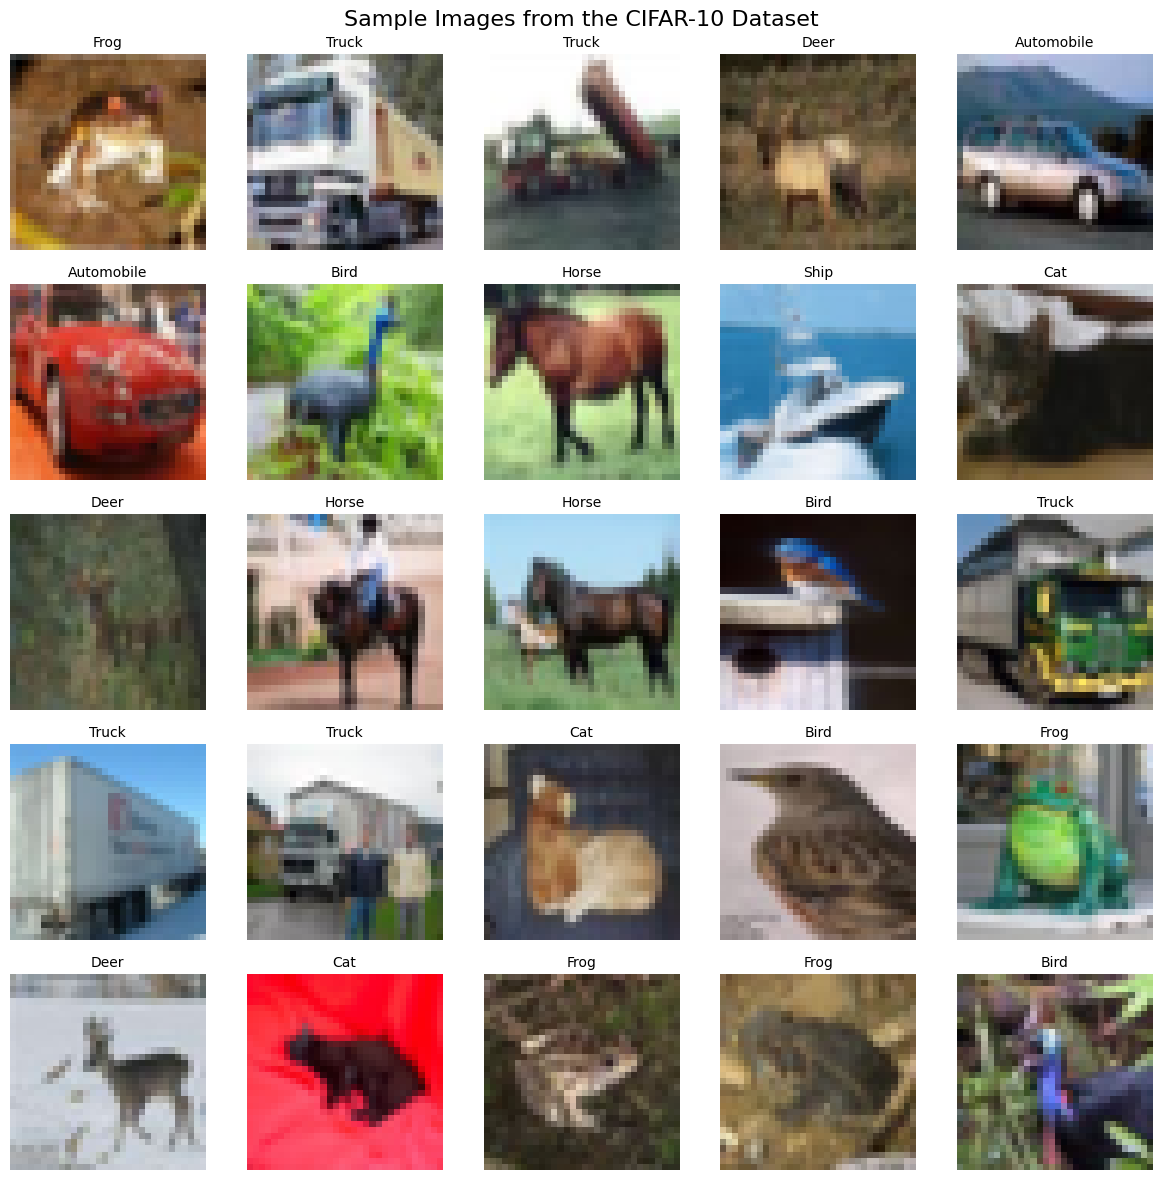

In [ ]:
# ==========================================================
# TASK 3: DISPLAY SAMPLE IMAGES FROM THE DATASET
# ==========================================================

# Display the first 25 images from the training dataset

plt.figure(figsize=(12, 12))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Images from the CIFAR-10 Dataset", fontsize=16)
plt.tight_layout()
plt.show()

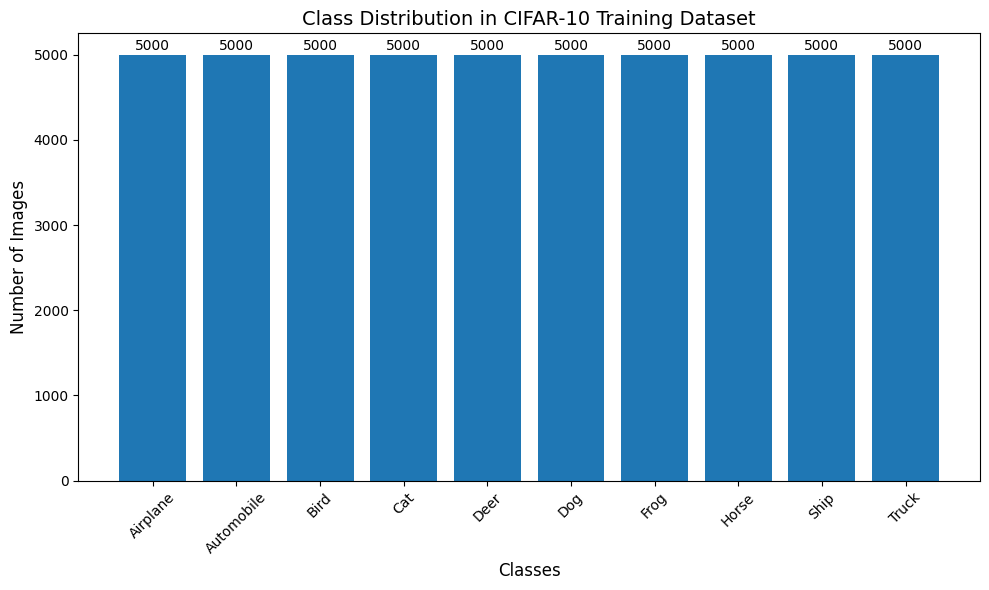

In [ ]:
# ==========================================================
# TASK 4: VISUALIZE CLASS DISTRIBUTION
# ==========================================================

# Count the number of images in each class
unique_classes, class_counts = np.unique(y_train, return_counts=True)

# Create the bar chart
plt.figure(figsize=(10, 6))

plt.bar(class_names, class_counts)

plt.title("Class Distribution in CIFAR-10 Training Dataset", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

# Rotate class names for better readability
plt.xticks(rotation=45)

# Display the count above each bar
for i, count in enumerate(class_counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# TASK 5: DATA PREPROCESSING
# ==========================================================

# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Display dataset information after preprocessing
print("=" * 50)
print("DATA PREPROCESSING COMPLETED")
print("=" * 50)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print("\nTraining Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

print("\nPixel Value Range After Normalization")
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

print("\nData Type :", X_train.dtype)

DATA PREPROCESSING COMPLETED
Training Data Shape : (50000, 32, 32, 3)
Testing Data Shape  : (10000, 32, 32, 3)

Training Labels Shape : (50000, 1)
Testing Labels Shape  : (10000, 1)

Pixel Value Range After Normalization
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0

Data Type : float32


In [ ]:
# ==========================================================
# FIX 1: CREATE TRAINING, VALIDATION AND TEST SETS
# ==========================================================

from sklearn.model_selection import train_test_split

# Flatten labels for stratified splitting
y_train_flat = y_train.reshape(-1)

# Split original training data into:
# 90% Training and 10% Validation
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train_flat
)

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)

print("Training Data   :", X_train_new.shape)
print("Validation Data :", X_val.shape)
print("Testing Data    :", X_test.shape)

print("Training Labels   :", y_train_new.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels    :", y_test.shape)

TRAIN / VALIDATION / TEST SPLIT
Training Data   : (45000, 32, 32, 3)
Validation Data : (5000, 32, 32, 3)
Testing Data    : (10000, 32, 32, 3)
Training Labels   : (45000, 1)
Validation Labels : (5000, 1)
Testing Labels    : (10000, 1)


In [17]:
# ==========================================================
# TASK 6: BUILD THE CONVOLUTIONAL NEURAL NETWORK (CNN)
# ==========================================================

# Create the CNN model
model = Sequential([

    # First Convolutional Block
    Conv2D(filters=32,
           kernel_size=(3,3),
           activation='relu',
           padding='same',
           input_shape=(32,32,3)),

    MaxPooling2D(pool_size=(2,2)),


    # Second Convolutional Block
    Conv2D(filters=64,
           kernel_size=(3,3),
           activation='relu',
           padding='same'),

    MaxPooling2D(pool_size=(2,2)),


    # Convert Feature Maps into 1D Vector
    Flatten(),


    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')

])

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# ==========================================================
# TASK 7: COMPILE THE CNN MODEL
# ==========================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


In [19]:
# ==========================================================
# TASK 8: DISPLAY MODEL SUMMARY
# ==========================================================

print("=" * 70)
print("CNN MODEL SUMMARY")
print("=" * 70)

model.summary()

CNN MODEL SUMMARY


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ==========================================================
# TASK 6: TRAIN THE MAIN CNN WITH PROPER VALIDATION SET
# ==========================================================

print("=" * 60)
print("CNN TRAINING STARTED")
print("=" * 60)

baseline_history = model.fit(
    X_train_new,
    y_train_new,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("=" * 60)
print("CNN TRAINING COMPLETED")
print("=" * 60)

CNN TRAINING STARTED
Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 64ms/step - accuracy: 0.3848 - loss: 1.6832 - val_accuracy: 0.5478 - val_loss: 1.2977
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.5151 - loss: 1.3518 - val_accuracy: 0.6182 - val_loss: 1.0921
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.5696 - loss: 1.2033 - val_accuracy: 0.6356 - val_loss: 1.0256
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.6059 - loss: 1.1160 - val_accuracy: 0.6488 - val_loss: 1.0185
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.6303 - loss: 1.0492 - val_accuracy: 0.6744 - val_loss: 0.9260
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 144s 63ms/step - accuracy: 0.6533 - loss: 0.9867 - val_accuracy: 0.6964 - val_loss: 0.8604
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 86s 61ms/step - accuracy: 0.6684 - loss: 0.9429 - val_accuracy: 0.7054 - val_loss: 0.8485
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/

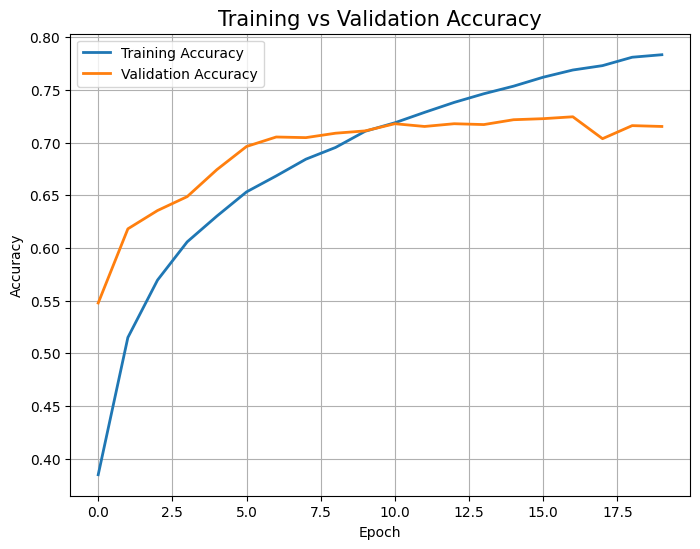

In [21]:
# ==========================================================
# MANDATORY PLOT: TRAINING AND VALIDATION ACCURACY
# ==========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    baseline_history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title("Training vs Validation Accuracy", fontsize=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

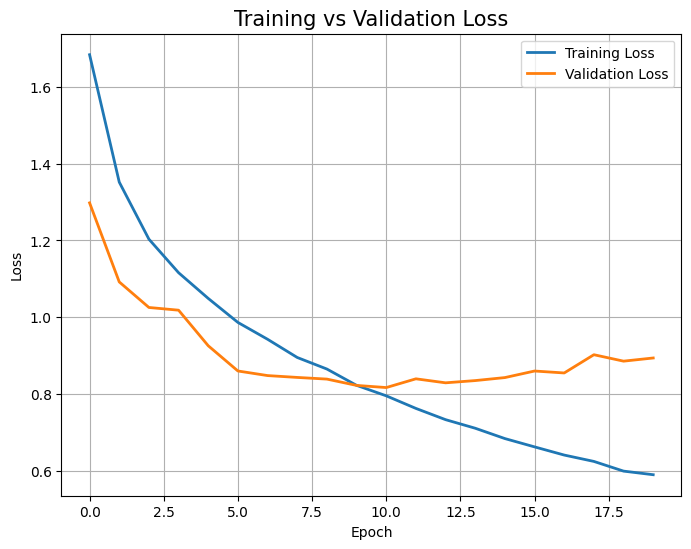

In [22]:
# ==========================================================
# MANDATORY PLOT: TRAINING AND VALIDATION LOSS
# ==========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    baseline_history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("Training vs Validation Loss", fontsize=15)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
# ==========================================================
# TASK 7: FINAL MODEL EVALUATION
# ==========================================================

# Evaluate the final model on the unseen test set
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Generate predictions
y_prob = model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# Convert actual labels to 1D
y_true = y_test.flatten()

print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

FINAL MODEL EVALUATION
Test Loss     : 0.9180
Test Accuracy : 0.7132


In [24]:
# ==========================================================
# TASK 7: PRECISION, RECALL AND F1-SCORE
# ==========================================================

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

PERFORMANCE METRICS
Accuracy  : 0.7132
Precision : 0.7203
Recall    : 0.7132
F1-Score  : 0.7149


In [25]:
# ==========================================================
# TASK 7: CLASSIFICATION REPORT
# ==========================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane       0.75      0.75      0.75      1000
  Automobile       0.83      0.83      0.83      1000
        Bird       0.64      0.54      0.58      1000
         Cat       0.48      0.59      0.53      1000
        Deer       0.63      0.69      0.66      1000
         Dog       0.64      0.61      0.63      1000
        Frog       0.78      0.78      0.78      1000
       Horse       0.83      0.72      0.77      1000
        Ship       0.86      0.80      0.83      1000
       Truck       0.76      0.82      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



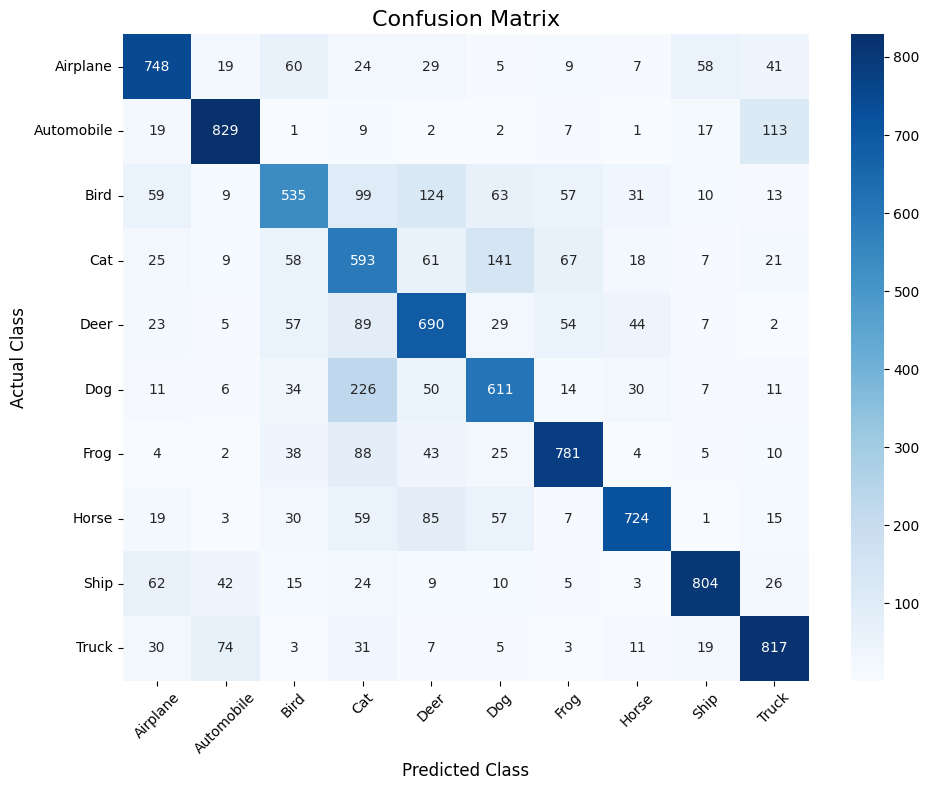

In [26]:
# ==========================================================
# TASK 7: CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# ==========================================================
# TASK 2: KERNEL SIZE COMPARISON
# ==========================================================

kernel_sizes = [
    (3, 3),
    (5, 5),
    (7, 7)
]

kernel_results = {}

for kernel in kernel_sizes:

    print("\n" + "=" * 60)
    print(f"Testing Kernel Size: {kernel}")
    print("=" * 60)

    temp_model = Sequential([

        Conv2D(
            filters=32,
            kernel_size=kernel,
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3)
        ),

        MaxPooling2D(
            pool_size=(2, 2)
        ),

        Conv2D(
            filters=64,
            kernel_size=kernel,
            activation='relu',
            padding='same'
        ),

        MaxPooling2D(
            pool_size=(2, 2)
        ),

        Flatten(),

        Dense(
            128,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            10,
            activation='softmax'
        )
    ])

    temp_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Record first convolution feature map size
    feature_map_size = tuple(
        temp_model.layers[0].output.shape[1:]
    )

    # Train using the same settings for fair comparison
    temp_model.fit(
        X_train_new,
        y_train_new,
        epochs=3,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    loss, accuracy = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    kernel_results[kernel] = {
        "feature_map_size": feature_map_size,
        "accuracy": accuracy
    }

    print("Feature Map Size :", feature_map_size)
    print(f"Test Accuracy    : {accuracy:.4f}")


Testing Kernel Size: (3, 3)
Feature Map Size : (32, 32, 32)
Test Accuracy    : 0.6397

Testing Kernel Size: (5, 5)
Feature Map Size : (32, 32, 32)
Test Accuracy    : 0.6033

Testing Kernel Size: (7, 7)
Feature Map Size : (32, 32, 32)
Test Accuracy    : 0.5830


In [44]:
# ==========================================================
# TASK 2: KERNEL SIZE RESULTS
# ==========================================================

print("\n" + "=" * 70)
print("KERNEL SIZE COMPARISON RESULTS")
print("=" * 70)

print(
    f"{'Kernel':<15}"
    f"{'Feature Map Size':<25}"
    f"{'Test Accuracy':<15}"
)

for kernel, result in kernel_results.items():

    print(
        f"{str(kernel):<15}"
        f"{str(result['feature_map_size']):<25}"
        f"{result['accuracy']:.4f}"
    )


KERNEL SIZE COMPARISON RESULTS
Kernel         Feature Map Size         Test Accuracy  
(3, 3)         (32, 32, 32)             0.6397
(5, 5)         (32, 32, 32)             0.6033
(7, 7)         (32, 32, 32)             0.5830


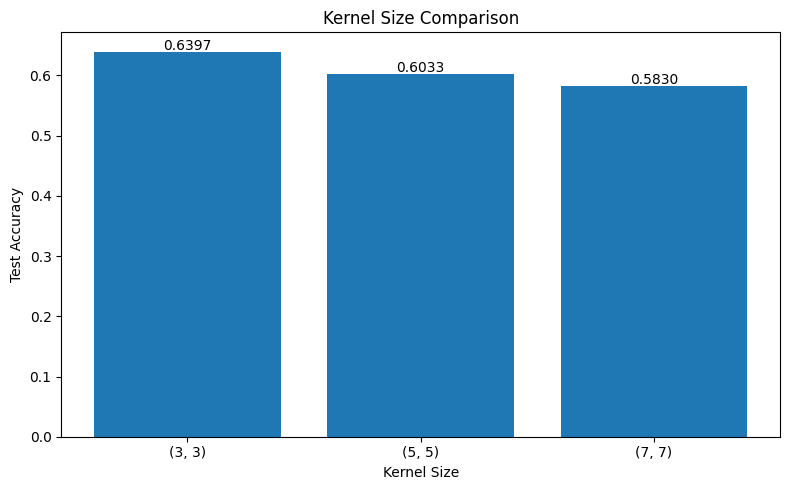

In [45]:
# ==========================================================
# TASK 2: KERNEL SIZE ACCURACY COMPARISON
# ==========================================================

labels = [
    str(kernel)
    for kernel in kernel_results.keys()
]

accuracies = [
    result["accuracy"]
    for result in kernel_results.values()
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    accuracies
)

plt.title("Kernel Size Comparison")
plt.xlabel("Kernel Size")
plt.ylabel("Test Accuracy")

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# TASK 2: KERNEL SIZE ACCURACY COMPARISON
# ==========================================================

labels = [
    str(kernel)
    for kernel in kernel_results.keys()
]

accuracies = [
    result["accuracy"]
    for result in kernel_results.values()
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    accuracies
)

plt.title("Kernel Size Comparison")
plt.xlabel("Kernel Size")
plt.ylabel("Test Accuracy")

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [15]:
import math

# ==========================================================
# TASK 3: PADDING COMPARISON
# ==========================================================

def calculate_output_size(input_size, kernel_size, stride, padding):
    if padding == 'same':
        # For 'same' padding, the output size is typically input_size / stride, rounded up
        # When stride is 1, output_size is input_size
        return math.ceil(input_size / stride)
    elif padding == 'valid':
        # For 'valid' padding, the output size is (input_size - kernel_size) / stride + 1, rounded down
        return math.floor((input_size - kernel_size) / stride) + 1
    else:
        raise ValueError("Padding must be 'same' or 'valid'")


padding_values = [
    "same",
    "valid"
]

print("=" * 60)
print("PADDING COMPARISON")
print("=" * 60)

for padding in padding_values:

    output_size = calculate_output_size(
        input_size=32,
        kernel_size=3,
        stride=1,
        padding=padding
    )

    print(
        f"Padding = {padding:<5} | "
        f"Output Size = {output_size} x {output_size}"
    )

PADDING COMPARISON
Padding = same  | Output Size = 32 x 32
Padding = valid | Output Size = 30 x 30


In [16]:
# ==========================================================
# TASK 3: COMPLETE STRIDE AND PADDING COMPARISON
# ==========================================================

stride_values = [1, 2]
padding_values = ["same", "valid"]

stride_padding_results = []

for stride in stride_values:

    for padding in padding_values:

        output_size = calculate_output_size(
            input_size=32,
            kernel_size=3,
            stride=stride,
            padding=padding
        )

        stride_padding_results.append(
            (
                stride,
                padding,
                output_size,
                output_size
            )
        )

print("=" * 75)
print("STRIDE AND PADDING OUTPUT DIMENSION COMPARISON")
print("=" * 75)

print(
    f"{'Stride':<10}"
    f"{'Padding':<12}"
    f"{'Output Height':<18}"
    f"{'Output Width':<15}"
)

for result in stride_padding_results:

    stride, padding, height, width = result

    print(
        f"{stride:<10}"
        f"{padding:<12}"
        f"{height:<18}"
        f"{width:<15}"
    )

STRIDE AND PADDING OUTPUT DIMENSION COMPARISON
Stride    Padding     Output Height     Output Width   
1         same        32                32             
1         valid       30                30             
2         same        16                16             
2         valid       15                15             


In [46]:
# ==========================================================
# TASK 5: POOLING OUTPUT DIMENSIONS
# ==========================================================

input_height = 32
input_width = 32

pool_size = 2
pool_stride = 2

output_height = (
    (input_height - pool_size) // pool_stride
) + 1

output_width = (
    (input_width - pool_size) // pool_stride
) + 1

print("=" * 60)
print("POOLING OUTPUT DIMENSION")
print("=" * 60)

print(
    f"Input Feature Map  : "
    f"{input_height} x {input_width}"
)

print(
    f"Pooling Window     : "
    f"{pool_size} x {pool_size}"
)

print(
    f"Pooling Stride     : "
    f"{pool_stride}"
)

print(
    f"Output Feature Map : "
    f"{output_height} x {output_width}"
)

POOLING OUTPUT DIMENSION
Input Feature Map  : 32 x 32
Pooling Window     : 2 x 2
Pooling Stride     : 2
Output Feature Map : 16 x 16


In [33]:
# ==========================================================
# TASK 5: MAX POOLING VS AVERAGE POOLING
# ==========================================================

pooling_results = {}

pooling_layers = {
    "MaxPooling": MaxPooling2D,
    "AveragePooling": AveragePooling2D
}

for pooling_name, PoolLayer in pooling_layers.items():

    print("\n" + "=" * 60)
    print(f"Training CNN with {pooling_name}")
    print("=" * 60)

    temp_model = Sequential([

        Conv2D(
            32,
            (3, 3),
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3)
        ),

        PoolLayer(
            pool_size=(2, 2)
        ),

        Conv2D(
            64,
            (3, 3),
            activation='relu',
            padding='same'
        ),

        PoolLayer(
            pool_size=(2, 2)
        ),

        Flatten(),

        Dense(
            128,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            10,
            activation='softmax'
        )
    ])

    temp_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    temp_model.fit(
        X_train_new,
        y_train_new,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    loss, accuracy = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    pooling_results[pooling_name] = accuracy

    print(f"Output Feature Map : 8 x 8")
    print(f"Test Accuracy      : {accuracy:.4f}")


Training CNN with MaxPooling


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Output Feature Map : 8 x 8
Test Accuracy      : 0.7099

Training CNN with AveragePooling


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Output Feature Map : 8 x 8
Test Accuracy      : 0.7021


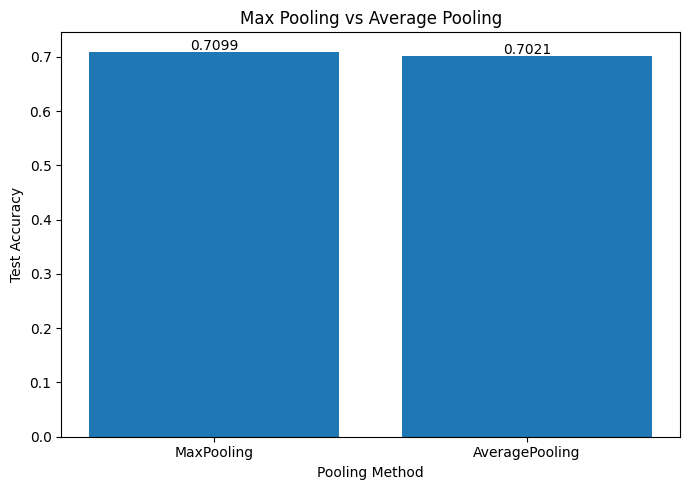

In [34]:
# ==========================================================
# TASK 5: POOLING ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(7, 5))

plt.bar(
    pooling_results.keys(),
    pooling_results.values()
)

plt.title("Max Pooling vs Average Pooling")
plt.xlabel("Pooling Method")
plt.ylabel("Test Accuracy")

for i, value in enumerate(pooling_results.values()):

    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [35]:
# ==========================================================
# ADDITIONAL EXERCISE 1:
# OUTPUT SIZE CALCULATION
# ==========================================================

N = 6
F = 5
S = 2
P = 2

output_size = (
    (N - F + 2 * P) // S
) + 1

print("=" * 60)
print("OUTPUT SIZE CALCULATION")
print("=" * 60)

print(f"Input Size : {N} x {N}")
print(f"Kernel     : {F} x {F}")
print(f"Stride     : {S}")
print(f"Padding    : {P}")

print(
    f"\nOutput Size = "
    f"({N} - {F} + 2({P})) / {S} + 1"
)

print(f"Output Size = {output_size} x {output_size}")

OUTPUT SIZE CALCULATION
Input Size : 6 x 6
Kernel     : 5 x 5
Stride     : 2
Padding    : 2

Output Size = (6 - 5 + 2(2)) / 2 + 1
Output Size = 3 x 3


In [36]:
# ==========================================================
# ADDITIONAL EXERCISE 2:
# CONVOLUTIONAL LAYER PARAMETER CALCULATION
# ==========================================================

filter_height = 3
filter_width = 3
input_channels = 3
number_of_filters = 64

parameters_per_filter = (
    filter_height
    * filter_width
    * input_channels
) + 1

total_parameters = (
    parameters_per_filter
    * number_of_filters
)

print("=" * 60)
print("CONVOLUTIONAL LAYER PARAMETER CALCULATION")
print("=" * 60)

print(
    f"Parameters per filter = "
    f"({filter_height} x {filter_width} x "
    f"{input_channels}) + 1"
)

print(
    f"Parameters per filter = "
    f"{parameters_per_filter}"
)

print(
    f"Total parameters = "
    f"{parameters_per_filter} x "
    f"{number_of_filters}"
)

print(
    f"\nTotal Trainable Parameters = "
    f"{total_parameters}"
)

CONVOLUTIONAL LAYER PARAMETER CALCULATION
Parameters per filter = (3 x 3 x 3) + 1
Parameters per filter = 28
Total parameters = 28 x 64

Total Trainable Parameters = 1792


In [37]:
# ==========================================================
# ADDITIONAL EXERCISE 3:
# RELU VS SIGMOID ACTIVATION
# ==========================================================

import time

activation_results = {}

activation_functions = [
    "relu",
    "sigmoid"
]

for activation in activation_functions:

    print("\n" + "=" * 60)
    print(f"Training CNN with {activation.upper()} Activation")
    print("=" * 60)

    temp_model = Sequential([

        Conv2D(
            32,
            (3, 3),
            activation=activation,
            padding='same',
            input_shape=(32, 32, 3)
        ),

        MaxPooling2D(
            (2, 2)
        ),

        Conv2D(
            64,
            (3, 3),
            activation=activation,
            padding='same'
        ),

        MaxPooling2D(
            (2, 2)
        ),

        Flatten(),

        Dense(
            128,
            activation=activation
        ),

        Dropout(0.5),

        Dense(
            10,
            activation='softmax'
        )
    ])

    temp_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.perf_counter()

    temp_model.fit(
        X_train_new,
        y_train_new,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    training_time = time.perf_counter() - start_time

    loss, accuracy = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    activation_results[activation] = {
        "accuracy": accuracy,
        "training_time": training_time
    }

    print(f"Test Accuracy : {accuracy:.4f}")
    print(f"Training Time : {training_time:.2f} seconds")


Training CNN with RELU Activation
Test Accuracy : 0.7015
Training Time : 1075.22 seconds

Training CNN with SIGMOID Activation
Test Accuracy : 0.5225
Training Time : 1119.24 seconds


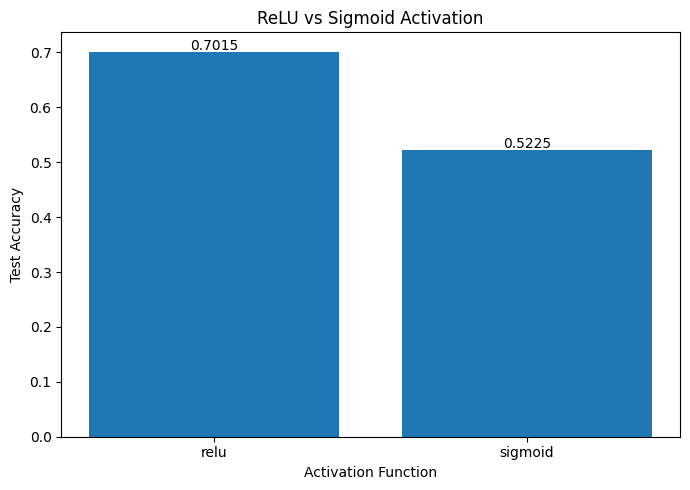

In [38]:
# ==========================================================
# RELU VS SIGMOID ACCURACY COMPARISON
# ==========================================================

labels = list(activation_results.keys())

accuracies = [
    activation_results[x]["accuracy"]
    for x in labels
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    accuracies
)

plt.title("ReLU vs Sigmoid Activation")
plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy")

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [39]:
# ==========================================================
# ADDITIONAL EXERCISE 5:
# EFFECT OF NUMBER OF FILTERS
# ==========================================================

import time

filter_values = [16, 32, 64]

filter_results = {}

for filters in filter_values:

    print("\n" + "=" * 60)
    print(f"Training CNN with {filters} Filters")
    print("=" * 60)

    temp_model = Sequential([

        Conv2D(
            filters=filters,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3)
        ),

        MaxPooling2D(
            (2, 2)
        ),

        Conv2D(
            filters=filters * 2,
            kernel_size=(3, 3),
            activation='relu',
            padding='same'
        ),

        MaxPooling2D(
            (2, 2)
        ),

        Flatten(),

        Dense(
            128,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            10,
            activation='softmax'
        )
    ])

    temp_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.perf_counter()

    temp_model.fit(
        X_train_new,
        y_train_new,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    training_time = time.perf_counter() - start_time

    loss, accuracy = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    parameter_count = temp_model.count_params()

    filter_results[filters] = {
        "accuracy": accuracy,
        "training_time": training_time,
        "parameters": parameter_count
    }

    print(f"Test Accuracy : {accuracy:.4f}")
    print(f"Training Time : {training_time:.2f} seconds")
    print(f"Parameters    : {parameter_count}")


Training CNN with 16 Filters
Test Accuracy : 0.6709
Training Time : 667.82 seconds
Parameters    : 268650

Training CNN with 32 Filters
Test Accuracy : 0.6938
Training Time : 1260.67 seconds
Parameters    : 545098

Training CNN with 64 Filters
Test Accuracy : 0.7169
Training Time : 2476.89 seconds
Parameters    : 1125642


In [40]:
# ==========================================================
# FILTER COMPARISON RESULTS
# ==========================================================

print("\n" + "=" * 85)
print("EFFECT OF NUMBER OF FILTERS")
print("=" * 85)

print(
    f"{'Filters':<12}"
    f"{'Test Accuracy':<18}"
    f"{'Training Time (s)':<22}"
    f"{'Parameters':<15}"
)

for filters, result in filter_results.items():

    print(
        f"{filters:<12}"
        f"{result['accuracy']:<18.4f}"
        f"{result['training_time']:<22.2f}"
        f"{result['parameters']:<15}"
    )


EFFECT OF NUMBER OF FILTERS
Filters     Test Accuracy     Training Time (s)     Parameters     
16          0.6709            667.82                268650         
32          0.6938            1260.67               545098         
64          0.7169            2476.89               1125642        


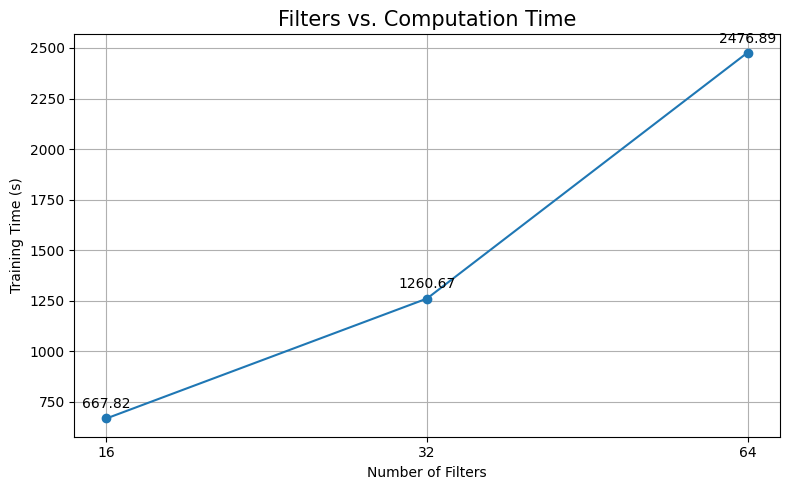

In [43]:
# ==========================================================
# FILTERS VS COMPUTATION TIME
# ==========================================================

training_times = [
    filter_results[x]["training_time"]
    for x in filter_values
]

plt.figure(figsize=(8, 5))

plt.plot(
    [str(x) for x in filter_values],
    training_times,
    marker='o',
    linestyle='-'
)

plt.title("Filters vs. Computation Time", fontsize=15)
plt.xlabel("Number of Filters")
plt.ylabel("Training Time (s)")
plt.grid(True)

for i, value in enumerate(training_times):
    plt.text(
        i,
        value + 50, # Adjust offset for better visibility
        f"{value:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

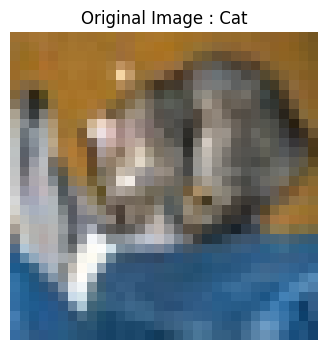

In [27]:
# ==========================================================
# TASK 12.1: DISPLAY A SAMPLE TEST IMAGE
# ==========================================================

# Select a test image
image_index = 0

sample_image = X_test[image_index]

# Display the image
plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title(f"Original Image : {class_names[y_test[image_index][0]]}")
plt.axis("off")
plt.show()

In [28]:
# ==========================================================
# TASK 12.2: CREATE FEATURE EXTRACTION MODEL
# ==========================================================

feature_model = Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output,   # First Conv2D Layer
        model.layers[2].output    # Second Conv2D Layer
    ]
)

print("Feature Extraction Model Created Successfully!")

Feature Extraction Model Created Successfully!


In [29]:
# ==========================================================
# TASK 12.3: GENERATE FEATURE MAPS
# ==========================================================

# Add batch dimension
sample = np.expand_dims(sample_image, axis=0)

# Predict feature maps
feature_maps = feature_model.predict(sample)

print("Feature Maps Generated Successfully!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Feature Maps Generated Successfully!


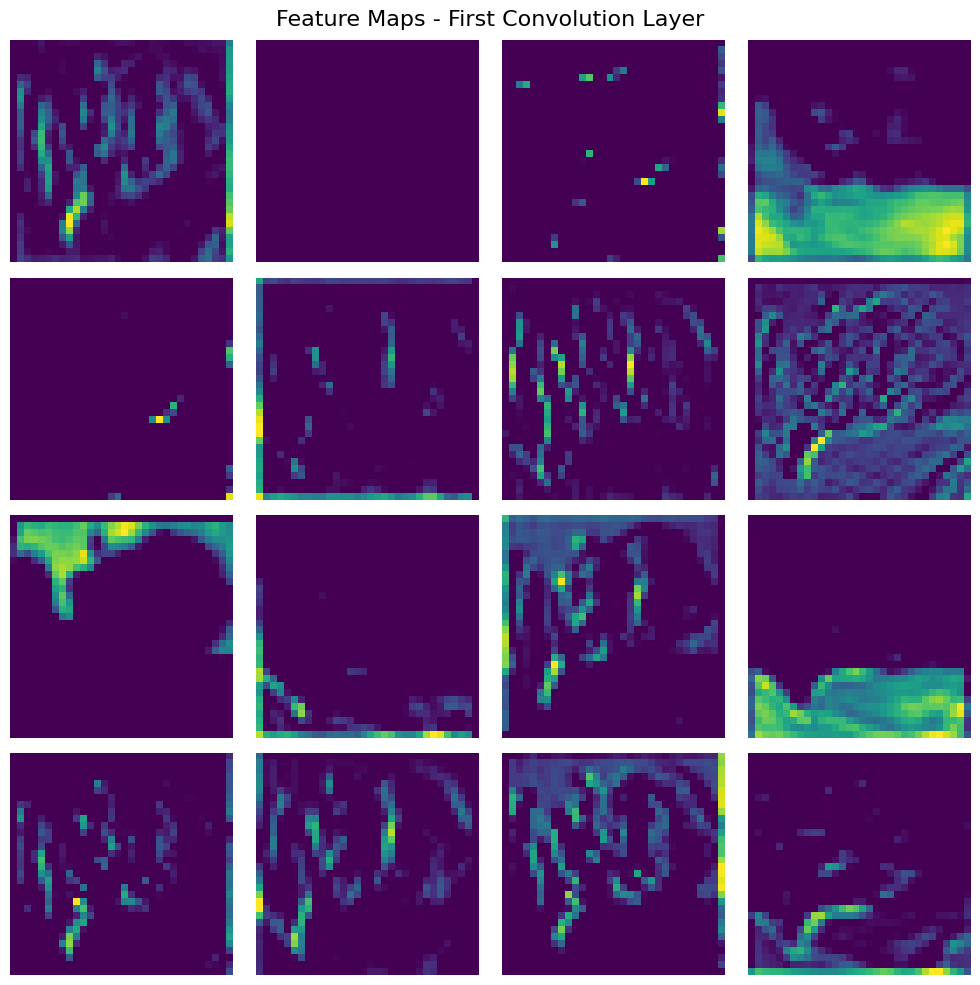

In [30]:
# ==========================================================
# TASK 12.4: FIRST CONVOLUTION LAYER FEATURE MAPS
# ==========================================================

feature_map_1 = feature_maps[0]

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_map_1[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps - First Convolution Layer", fontsize=16)
plt.tight_layout()
plt.show()

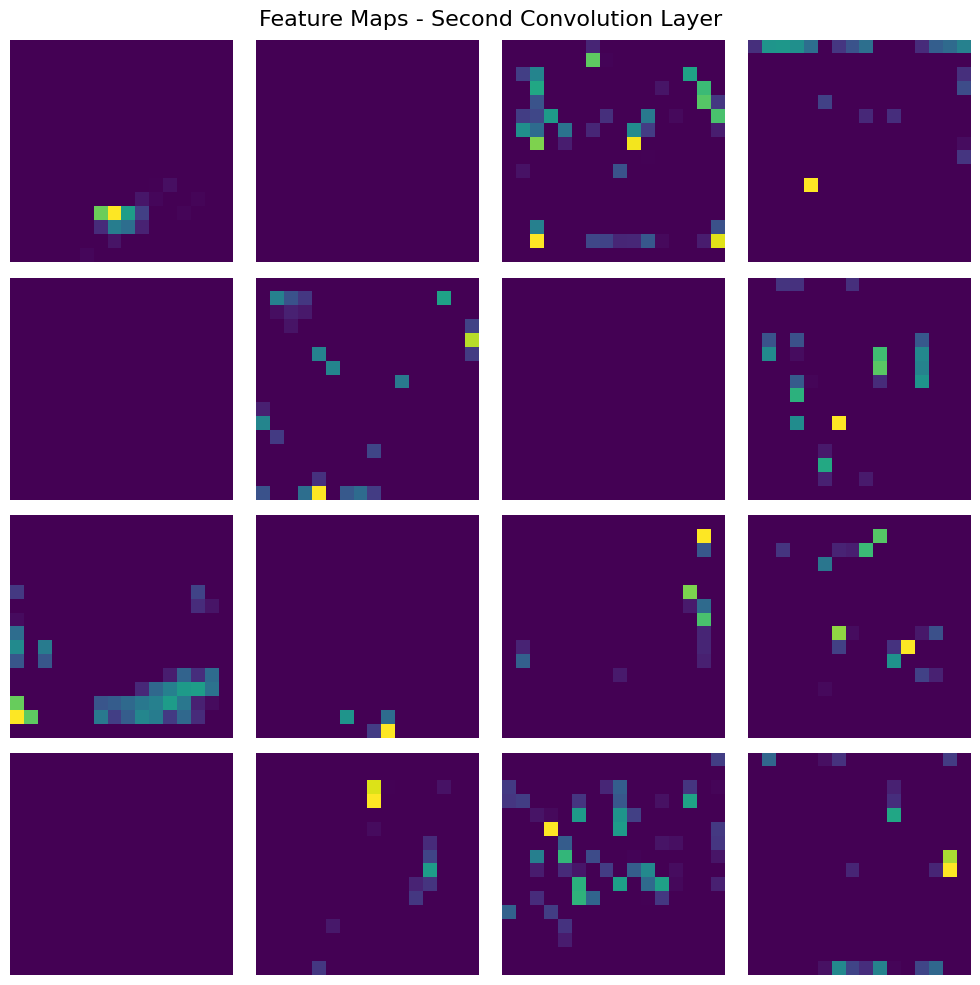

In [31]:
# ==========================================================
# TASK 12.5: SECOND CONVOLUTION LAYER FEATURE MAPS
# ==========================================================

feature_map_2 = feature_maps[1]

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_map_2[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps - Second Convolution Layer", fontsize=16)
plt.tight_layout()
plt.show()